# 2_PyNutil_cell_mapping


This notebook maps Imaris-detected cells from a high-resolution ND2 scan into the pixel
coordinate frame of a low-resolution whole-brain ND2 scan (numpy / image
convention: X = column, Y = row, origin at the top-left pixel).
Output feeds PyNUtil for per-region cell counts against registration results.

The mapping is a pure scale + translation built entirely from ND2 metadata
(no pixel data is loaded):

    X_low = csv_x_um / voxel_low + Ax
    Y_low = csv_y_um / voxel_low + Ay

It composes two metadata steps:
  1. Cell within the high-res FOV:
        hi_px = (csv_um - origin_corner) / voxel_hi
     where origin_corner is the high-res nd2 `stagePositionUm` (the Imaris
     ExtMin the CSV µm are measured from).
  2. FOV within the low-res image: the two limnd2 stitch centers are the
     calculated large-image centers; their difference (axis signs
     STAGE_PIXEL_SIGN) places the high-res FOV inside the low-res image.

These metadata field meanings are decoded assumptions (see project notes); the
resulting placements are verified separately. This script assumes they hold.

This notebook was adapted from code originally written by Igor from Neuroinformatics Unit. The original code is provided at the bottom of this notebook.

Requires: pandas, nd2, limnd2, brainglobe-atlasapi, PyNutil.

## How to use

1. Set all paths and settings in the **Configuration** cell below.
2. Run all cells in order.
3. To process a specific animal: `run("animal_ID")`  
   To process all animals: `run()`



### Expected folder layout:

```
ND2_BASE/
    {animal_id}/
        {experiment_name}_{animal_id}_{imaging_string}_{section}_{roi_1}_Stitched.nd2
        {experiment_name}_{animal_id}_{imaging_string}_{section}_{roi_2}_Stitched.nd2
        {experiment_name}_{animal_id}_{imaging_string}_{section}_wholebrain-Stitched.nd2

CSV_BASE/
    {experiment_name}_{animal_id}_{imaging_string}_{section}_{roi_1}_Statistics/
        OnePageMultiComponent_Detailed_Statistics/
            Surface_*.csv

JSON_BASE/
    {animal_id}/
        {animal_id}_registration_aligned.json
```

### Output files:
Per section:

1. `cells_lowres.csv` — coordinates of every detected cell in low-resolution pixel space (X, Y, section number, component name)
2. `counts.csv — cell` counts per atlas brain region, semicolon-separated (main PyNutil output)
3. `meshview.json` — 3D visualisation file viewable in the EBrains MeshView browser tool

Per animal: 

1. `(animal_ID)_NeuN.xlsx`: compiled Excel file with a single Counts sheet containing all brain regions × all sections, with left/right/total cell counts and area measurements


In [2]:
from __future__ import annotations

import re
from collections import defaultdict
from pathlib import Path

import pandas as pd
import limnd2
import nd2
import json

from brainglobe_atlasapi import BrainGlobeAtlas
import PyNutil as pnt

## Configuration

Edit the settings below before running. Items marked ` <-- CHANGE` should be set for your experiment.

In [3]:
# ── Folder paths ──────────────────────────────────────────────────────────────

# Folder containing all ND2 files. Expected: one subfolder per animal ID.
ND2_BASE  = Path("/Volumes/Extreme SSD/PyNutil_registration_test/raw_nd2")                               # <-- CHANGE

# Folder containing Imaris statistics exports.
CSV_BASE  = Path("/Volumes/Extreme SSD/PyNutil_registration_test/cell_counting_data")                    # <-- CHANGE

# Folder containing QuickNII registration JSON files.
JSON_BASE = Path("/Volumes/Extreme SSD/PyNutil_registration_test/registration_images")                   # <-- CHANGE

# Root output folder. Subfolders are created automatically per animal/section.
OUT_BASE  = Path("/Volumes/Extreme SSD/PyNutil_registration_test/cell_mapping_output")                   # <-- CHANGE



# ── File naming ───────────────────────────────────────────────────────────────

# Prefix used at the start of all your image filenames.

EXPERIMENT_PREFIX = "RELNCOLBOS"                                                                         # <-- CHANGE

# The imaging channel/date string embedded in your filenames between the
# animal ID and section number.
# Example: if your file is EXP_1125706_NeuN-488_DAPI_20250101_s1_left_Stitched.nd2
#          set this to "NeuN-488_DAPI_20250101"

IMAGING_STRING = "NeuN-488_Reelin-568_13042026"                                                          # <-- CHANGE

# Extract the section number from folder/file names.
# Looks for digits immediately after the experiment prefix.
# Example: for a file named "EXPERIMENT_1125706_NeuN_s1_left_Stitched.nd2", this extracts "1125706".

ANIMAL_ID_PATTERN = rf'{EXPERIMENT_PREFIX}_(\d+)_'                                                       # <-- CHANGE if needed

# Names of ROI subfolders (the different fields of view imaged per section).
# For bilateral imaging with left and right hemispheres: ["left", "right"]
# For a single whole-field ROI: ["wholebrain"]
# The script will look for folders whose names contain these strings.

ROI_NAMES = ["left-entorhinal", "right-entorhinal"]                                                      # <-- CHANGE
 
# Identify the wholebrain (low-resolution) ND2 file. This finds file names that contain the string below

WHOLEBRAIN_SUFFIX = "wholebrain-Stitched"                                                                # <-- CHANGE if needed

# Pattern for the QuickNII registration JSON filename.
# {animal} will be replaced with the animal ID.

JSON_FILENAME_PATTERN = "{animal}_registration_aligned.json"                                            # <-- CHANGE if needed



# ── Cell counting settings ────────────────────────────────────────────────────

# Component name to extract from Imaris statistics CSV.
# Must match exactly the component name shown in your Imaris surface statistics.
# Run the notebook once to see all component names printed during CSV loading.

COMPONENT_FILTER = ["NeuN"]                                # <-- CHANGE if needed
COMPONENT_LABEL  = "NeuN"                                  # <-- CHANGE if needed



# ── Microscope-specific settings ──────────────────────────────────────────────

# IMPORTANT: STAGE_PIXEL_SIGN must be verified for your specific microscope.
# It defines the direction of the stage-µm axes relative to image pixel axes.
# (-1, +1) means X axis is inverted, Y axis is aligned.
# If your cell placements appear mirrored, try (+1, +1) or (-1, -1).
# Verify by overlaying cells_lowres.csv onto the wholebrain image after processing one test section before running the full batch.

STAGE_PIXEL_SIGN = (-1, +1)                                # <-- VERIFY for your microscope

## Coordinate conversion functions

These functions read ND2 metadata to calculate the affine transform
that maps Imaris cell coordinates (µm) into low-resolution image pixel coordinates.

In [5]:
def voxel_xy_um(path: Path) -> float:
    """In-plane pixel size (µm/px). Assumes square pixels (x == y)."""
    with nd2.ND2File(path) as im:
        vs = im.voxel_size()
    if abs(vs.x - vs.y) > 1e-6:
        raise ValueError(f"Non-square pixels in {path}: {vs.x} vs {vs.y}")
    return float(vs.x)


def image_size_wh(path: Path) -> tuple[int, int]:
    """Image (width, height) in pixels."""
    with nd2.ND2File(path) as im:
        return im.sizes["X"], im.sizes["Y"]


def stitch_center_um(path: Path) -> tuple[float, float]:
    """Calculated stage-XY centre of a stitched ND2, via limnd2 recordedData."""
    with limnd2.Nd2Reader(path) as r:
        data = r.recordedData.data
        return float(data[2].data[0]), float(data[3].data[0])


def origin_corner_um(path: Path) -> tuple[float, float]:
    """Stage-XY of the high-res image origin corner (pixel 0,0), via the nd2 lib."""
    with nd2.ND2File(path) as im:
        p = im.frame_metadata(0).channels[0].position.stagePositionUm
    return float(p.x), float(p.y)


def metadata_affine(
    highres: Path, lowres: Path,
    voxel_hi: float, voxel_lo: float,
    lo_W: int, lo_H: int,
) -> tuple[float, float]:
    """CSV-µm -> low-res-pixel affine (Ax, Ay), from metadata only."""
    Wh, Hh = image_size_wh(highres)
    ox, oy = origin_corner_um(highres)
    hcx, hcy = stitch_center_um(highres)
    lcx, lcy = stitch_center_um(lowres)
    sx, sy = STAGE_PIXEL_SIGN
    scale = voxel_hi / voxel_lo

    fov_cx = lo_W / 2 + sx * (hcx - lcx) / voxel_lo
    fov_cy = lo_H / 2 + sy * (hcy - lcy) / voxel_lo
    fov_x0 = fov_cx - Wh * scale / 2
    fov_y0 = fov_cy - Hh * scale / 2

    Ax = fov_x0 - ox / voxel_lo
    Ay = fov_y0 - oy / voxel_lo
    return Ax, Ay

In [6]:
def read_cells(csv_path: Path, component_filter: list[str] | None = None) -> pd.DataFrame:
    """Load the Imaris detailed statistics CSV and optionally filter by component.

    Skips preamble rows by finding the line containing 'Position X'.
    If component_filter is provided, only rows whose Component Name matches
    (case-insensitive) are kept.
    """
    with open(csv_path, encoding="utf-8") as f:
        header_row = next(i for i, line in enumerate(f) if "Position X" in line)
    cells = pd.read_csv(csv_path, skiprows=header_row)
    cells = cells.dropna(subset=["Position X [µm]", "Position Y [µm]"])

    if "Component Name" in cells.columns:
        counts = cells["Component Name"].value_counts()
        print(f"      Components found in CSV ({len(cells)} total rows):")
        for comp, n in counts.items():
            print(f"        {comp}: {n}")
    else:
        print("      WARNING: 'Component Name' column not found in CSV")

    if component_filter is not None and "Component Name" in cells.columns:
        keep = [c.lower() for c in component_filter]
        cells = cells[cells["Component Name"].str.strip().str.lower().isin(keep)]
        print(f"      After filter ({', '.join(component_filter)}): {len(cells)} cells")
        if len(cells) == 0:
            print("      WARNING: 0 cells remain after filtering — check COMPONENT_FILTER names match the CSV")

    return cells.reset_index(drop=True)

## Discover available sections

Scans CSV_BASE to find all available sections and animals.
Any sections with missing ND2 or JSON files are reported and skipped.

In [7]:
def build_sections():
    csv_base  = Path(CSV_BASE)
    nd2_base  = Path(ND2_BASE)
    json_base = Path(JSON_BASE)

    groups  = defaultdict(list)
    skipped = []

    for stats_folder in sorted(csv_base.iterdir()):
        if not stats_folder.is_dir():
            continue

        name = stats_folder.name

        # Extract animal ID
        m_animal = re.search(ANIMAL_ID_PATTERN, name)
        # Extract section number
        m_section = re.search(r'_(s\d+)_', name)
        # Match any configured ROI name
        roi_match = next((roi for roi in ROI_NAMES if roi.lower() in name.lower()), None)

        if not (m_animal and m_section and roi_match):
            skipped.append(f"Could not parse: {name}")
            continue

        animal  = m_animal.group(1)
        section = m_section.group(1)
        roi     = roi_match
        sec_num = int(section[1:])

        # Construct high-res ND2 filename from configured template
        stem = f"{EXPERIMENT_PREFIX}_{animal}_{IMAGING_STRING}_{section}_{roi}_Stitched"
        highres_path = nd2_base / animal / f"{stem}.nd2"

        det_folder = stats_folder / "OnePageMultiComponent_Detailed_Statistics"
        csv_files  = list(det_folder.glob("Surface_*.csv")) if det_folder.exists() else []

        missing = []
        if not highres_path.exists(): missing.append(f"highres ND2: {highres_path.name}")
        if not csv_files:             missing.append("Detailed Statistics CSV")

        if missing:
            skipped.append(f"{animal} {section} {roi} — missing: {', '.join(missing)}")
            continue

        groups[(animal, sec_num)].append({
            "roi":     roi,
            "highres": str(highres_path),
            "csv":     str(csv_files[0]),
        })

    sections = []
    for (animal, sec_num), rois in sorted(groups.items()):
        section      = f"s{sec_num}"
        lowres_path  = nd2_base / animal / f"{EXPERIMENT_PREFIX}_{animal}_{IMAGING_STRING}_{section}_{WHOLEBRAIN_SUFFIX}.nd2"
        json_path    = json_base / animal / JSON_FILENAME_PATTERN.format(animal=animal)
        out_path     = OUT_BASE / animal / COMPONENT_LABEL / section

        missing = []
        if not lowres_path.exists(): missing.append(f"lowres ND2: {lowres_path.name}")
        if not json_path.exists():   missing.append(f"JSON: {json_path.name}")

        if missing:
            skipped.append(f"{animal} {section} — missing: {', '.join(missing)}")
            continue

        sections.append({
            "animal":         animal,
            "section":        sec_num,
            "rois":           rois,
            "lowres":         str(lowres_path),
            "alignment_path": str(json_path),
            "out":            str(out_path),
        })

    print(f"Found {len(sections)} sections to process")
    if skipped:
        print(f"Skipped {len(skipped)}:")
        for s in skipped: print(f"  {s}")

    return sections

sections = build_sections()

Found 6 sections to process
Skipped 11:
  1125841 s1 right-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s1_right-entorhinal_Stitched.nd2
  1125841 s2 left-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s2_left-entorhinal_Stitched.nd2
  1125841 s2 right-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s2_right-entorhinal_Stitched.nd2
  1125841 s3 left-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s3_left-entorhinal_Stitched.nd2
  1125841 s3 right-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s3_right-entorhinal_Stitched.nd2
  1125841 s4 left-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s4_left-entorhinal_Stitched.nd2
  1125841 s4 right-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s4_right-entorhinal_Stitched.nd2
  1125841 s5 left-ent

## Process sections

Processes all sections by animal. Results are saved to OUT_BASE.

Each output folder contains:
- `cells_lowres.csv` — cell positions in low-res pixel coordinates
- `counts.csv` — per-region cell counts (main PyNutil output)
- `meshview.json` — viewable in the EBrains MeshView viewer
- `rois.json` — source ND2 filenames for traceability

In [8]:
def process_section_group(group: dict, component_filter: list[str] | None = None) -> pd.DataFrame:
    """
    Map cells from all ROIs of one section into low-res pixel coordinates,
    combine them, run PyNUtil, and write outputs to group['out'].
    """
    subject    = group["animal"]
    sec_num    = group["section"]
    lowres     = Path(group["lowres"])
    align_path = Path(group["alignment_path"])
    out_path   = Path(group["out"])

    voxel_lo = voxel_xy_um(lowres)
    lo_W, lo_H = image_size_wh(lowres)

    all_cells: list[pd.DataFrame] = []

    for roi in group["rois"]:
        voxel_hi = voxel_xy_um(roi["highres"])
        Ax, Ay = metadata_affine(roi["highres"], lowres, voxel_hi, voxel_lo, lo_W, lo_H)

        cells = read_cells(roi["csv"], component_filter)
        x = cells["Position X [µm]"] / voxel_lo + Ax
        y = cells["Position Y [µm]"] / voxel_lo + Ay

        result = pd.DataFrame({
            "X":              x.values,
            "Y":              y.values,
            "image_width":    lo_W,
            "image_height":   lo_H,
            "section number": sec_num,
            "component":      cells["Component Name"].values
                              if "Component Name" in cells.columns
                              else [""] * len(cells),
        })

        inbounds = ((x >= 0) & (x < lo_W) & (y >= 0) & (y < lo_H)).mean()
        print(f"    {roi['roi']}: {len(result)} cells  ({inbounds:.0%} within bounds)")
        if inbounds < 1.0:
            print(f"      WARNING: {1 - inbounds:.0%} of cells fall outside the image — check STAGE_PIXEL_SIGN")

        all_cells.append(result)

    combined = pd.concat(all_cells, ignore_index=True)

    out_path.mkdir(parents=True, exist_ok=True)
    combined.to_csv(out_path / "cells_lowres.csv", index=False, float_format="%.3f")


    atlas      = BrainGlobeAtlas("allen_mouse_25um")
    alignment  = pnt.read_alignment(str(align_path))
    pnt_result = pnt.xy_to_coords(combined, alignment, atlas)
    label_df   = pnt.quantify_coords(pnt_result, atlas)
    pnt.save_analysis(out_path, pnt_result, atlas, label_df=label_df)

    print(f"  → {len(combined)} total cells saved to {out_path.name}")
    return combined

In [ ]:
def run(subject: str | list[str] | None = None) -> None:
    """
    Discover and process sections.

    Parameters
    ----------
    subject : str, list of str, or None
        Animal ID(s) to process. Pass None to process all animals found.

    Examples
    --------
        run("1125706")               # one animal
        run(["1125706", "1125866"])  # specific animals
        run()                        # all animals
    """
    print(f"Scanning for sections in: {CSV_BASE}\n")
    sections = build_sections()

    if not sections:
        print("No sections to process.")
        return

    by_subject: dict[str, list] = defaultdict(list)
    for s in sections:
        by_subject[s["animal"]].append(s)

    all_subjects = sorted(by_subject.keys())
    if subject is None:
        subjects = all_subjects
    else:
        requested = [subject] if isinstance(subject, str) else list(subject)
        missing = set(requested) - set(all_subjects)
        if missing:
            print(f"WARNING: subject(s) not found: {', '.join(sorted(missing))}")
        subjects = [subj for subj in all_subjects if subj in requested]

    if not subjects:
        print("No matching subjects to process.")
        return

    print(f"Found {sum(len(by_subject[s]) for s in subjects)} section(s) "
          f"across {len(subjects)} animal(s):\n")
    for subj in subjects:
        secs = by_subject[subj]
        sec_labels = ", ".join(
            f"s{s['section']}({'+'.join(r['roi'] for r in s['rois'])})"
            for s in secs
        )
        print(f"  {subj}: {sec_labels}")
    print()

    for i, subj in enumerate(subjects):
        print(f"{'─' * 60}")
        print(f"Animal {i + 1}/{len(subjects)}: {subj}")
        print(f"{'─' * 60}")

        for s in by_subject[subj]:
            rois = [r["roi"] for r in s["rois"]]
            print(f"\n  s{s['section']}  ({', '.join(rois)})")
            process_section_group(s, component_filter=COMPONENT_FILTER)

        print(f"\n✓ {subj} complete — results in {OUT_BASE}")

    print("\nDone.")

run("1125706")                                   # <-------------------------- replace with run("animal_ID") to process a single animal

Scanning for sections in: /Volumes/Extreme SSD/PyNutil_registration_test/cell_counting_data

Found 6 sections to process
Skipped 11:
  1125841 s1 right-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s1_right-entorhinal_Stitched.nd2
  1125841 s2 left-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s2_left-entorhinal_Stitched.nd2
  1125841 s2 right-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s2_right-entorhinal_Stitched.nd2
  1125841 s3 left-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s3_left-entorhinal_Stitched.nd2
  1125841 s3 right-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s3_right-entorhinal_Stitched.nd2
  1125841 s4 left-entorhinal — missing: highres ND2: RELNCOLBOS_1125841_NeuN-488_Reelin-568_13042026_s4_left-entorhinal_Stitched.nd2
  1125841 s4 right-entorhinal — missing: highres ND2: RELNCOLBO

## Extract whole-brain region counts

Reads all `counts.csv` files output by PyNutil and compiles them into
a per-animal Excel file containing counts for every atlas region.

To restrict to specific brain regions, filter the resulting DataFrame
by the `region` column after loading.

In [9]:
def read_section_counts(counts_path: Path, section: str) -> pd.DataFrame:
    """Read one counts.csv and return all region rows."""
    df = pd.read_csv(counts_path, sep=";")
    df["section"] = section
    return df[[
        "section", "name",
        "left_hemi_object_count", "right_hemi_object_count", "object_count",
        "left_hemi_region_area",  "right_hemi_region_area",  "region_area",
        "left_hemi_area_fraction","right_hemi_area_fraction", "area_fraction",
    ]].rename(columns={
        "name":                     "region",
        "left_hemi_object_count":   "left_count",
        "right_hemi_object_count":  "right_count",
        "object_count":             "total_count",
        "left_hemi_region_area":    "left_area_px",
        "right_hemi_region_area":   "right_area_px",
        "region_area":              "total_area_px",
        "left_hemi_area_fraction":  "left_area_fraction",
        "right_hemi_area_fraction": "right_area_fraction",
        "area_fraction":            "total_area_fraction",
    })


def extract_counts(pynutil_base: str, component: str) -> None:
    base = Path(pynutil_base)

    animal_dirs = sorted(d for d in base.iterdir() if d.is_dir())
    if not animal_dirs:
        print(f"No animal folders found in {base}")
        return

    for animal_dir in animal_dirs:
        animal   = animal_dir.name
        comp_dir = animal_dir / component
        if not comp_dir.exists():
            print(f"  SKIP {animal}: no '{component}' folder")
            continue

        section_dirs = sorted(d for d in comp_dir.iterdir() if d.is_dir())
        count_rows = []

        for sec_dir in section_dirs:
            section     = sec_dir.name
            counts_path = sec_dir / "counts.csv"

            if not counts_path.exists():
                print(f"  WARNING: no counts.csv in {animal}/{component}/{section}")
                continue

            count_rows.append(read_section_counts(counts_path, section))

        if not count_rows:
            print(f"  SKIP {animal}: no counts.csv files found")
            continue

        counts_df = pd.concat(count_rows, ignore_index=True).sort_values(["section", "region"])

        out_path = animal_dir / f"{animal}_{component}.xlsx"
        with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
            counts_df.to_excel(writer, sheet_name="Counts", index=False)

            ws = writer.sheets["Counts"]
            for col in ws.columns:
                max_len = max(len(str(c.value or "")) for c in col)
                ws.column_dimensions[col[0].column_letter].width = min(max_len + 3, 60)

        print(f"  {animal}: {len(section_dirs)} section(s), {len(count_rows)} with data → {out_path.name}")

    print("\nDone.")

extract_counts(pynutil_base=str(OUT_BASE), component=COMPONENT_LABEL)

  1125706: 6 section(s), 6 with data → 1125706_NeuN.xlsx
  1125841: 5 section(s), 5 with data → 1125841_NeuN.xlsx

Done.


## Optional: visualising cell counts using BrainGlobe heatmap

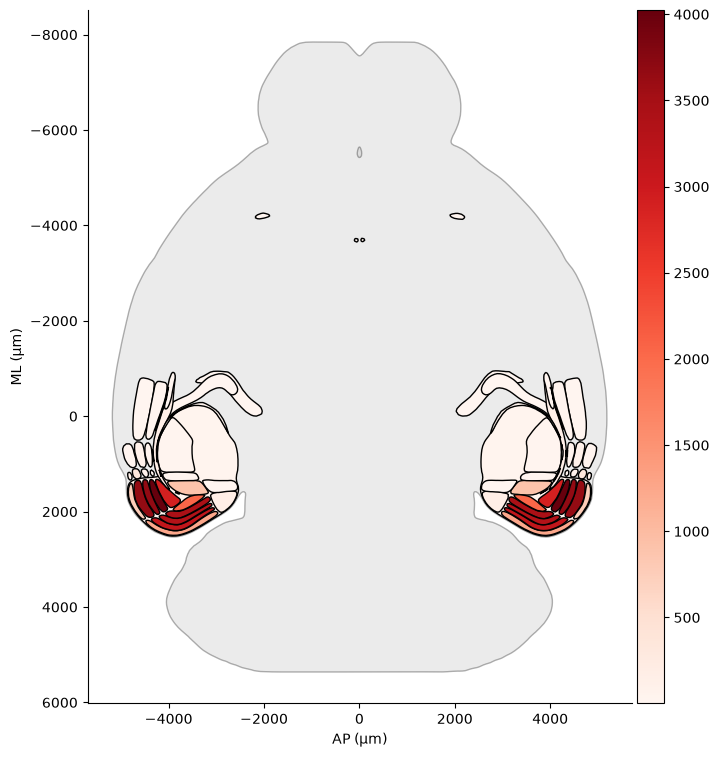

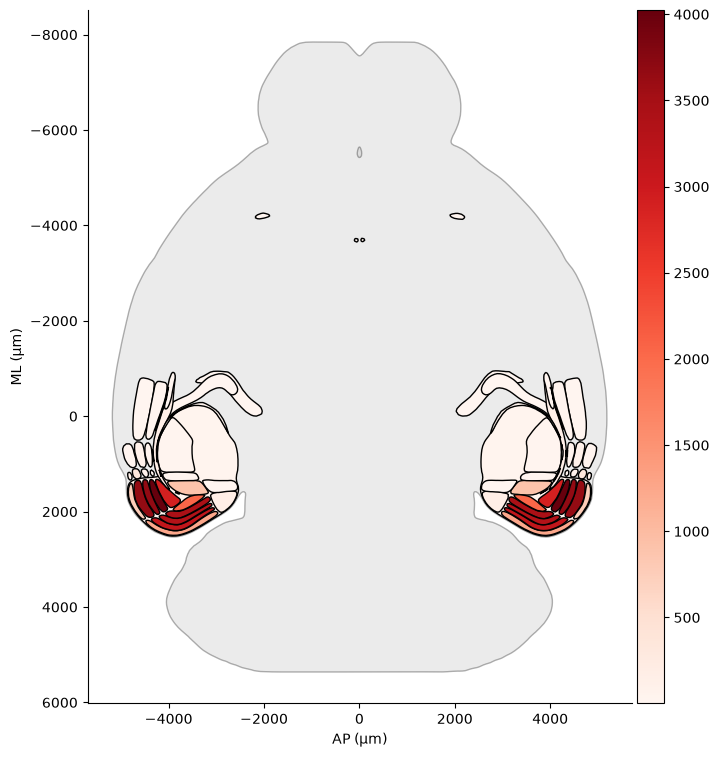

In [26]:
import brainglobe_heatmap as bgh

# ── Settings ──────────────────────────────────────────────────────────────────
animal    = "1125706"                                           # <-- CHANGE
component = COMPONENT_LABEL
position  = 4000                                                # depth of section in µm — adjust as needed
# ─────────────────────────────────────────────────────────────────────────────

all_counts = []
for sec_dir in sorted((OUT_BASE / animal / component).iterdir()):
    counts_path = sec_dir / "counts.csv"
    if counts_path.exists():
        all_counts.append(pd.read_csv(counts_path, sep=";"))

counts_df    = pd.concat(all_counts, ignore_index=True)
region_counts = counts_df.groupby("name")["object_count"].sum()

atlas = BrainGlobeAtlas("allen_mouse_25um")
name_to_acronym = atlas.lookup_df.set_index("name")["acronym"].to_dict()

values = {
    name_to_acronym[name]: int(count)
    for name, count in region_counts.items()
    if name in name_to_acronym and count > 0
}

bgh.Heatmap(
    values,
    position=position,
    orientation="horizontal",   # options: "frontal", "sagittal", "horizontal"
    thickness=2000,
    cmap="Reds",
    format="2D",
).show(xlabel="AP (µm)", ylabel="ML (µm)")

## Original code developed by Igor

In [ ]:
#!/usr/bin/env python3
"""
Map Imaris-detected cells from a high-resolution ND2 scan into the pixel
coordinate frame of a low-resolution whole-brain ND2 scan (numpy / image
convention: X = column, Y = row, origin at the top-left pixel).

Output feeds PyNUtil for per-region cell counts against registration results.

The mapping is a pure scale + translation built entirely from ND2 metadata
(no pixel data is loaded):

    X_low = csv_x_um / voxel_low + Ax
    Y_low = csv_y_um / voxel_low + Ay

It composes two metadata steps:
  1. Cell within the high-res FOV:
        hi_px = (csv_um - origin_corner) / voxel_hi
     where origin_corner is the high-res nd2 `stagePositionUm` (the Imaris
     ExtMin the CSV µm are measured from).
  2. FOV within the low-res image: the two limnd2 stitch centers are the
     calculated large-image centers; their difference (axis signs
     STAGE_PIXEL_SIGN) places the high-res FOV inside the low-res image.

These metadata field meanings are decoded assumptions (see project notes); the
resulting placements are verified separately. This script assumes they hold.

Add sections to SECTIONS below and run the file to process them all.
Requires: pandas, nd2, limnd2.
"""
from pathlib import Path

import pandas as pd
import limnd2
import nd2

from brainglobe_atlasapi import BrainGlobeAtlas  # noqa: E402
import PyNutil as pnt  # noqa: E402

# Direction of the stage-µm axes relative to the low-res image pixel axes,
# determined empirically for this microscope (X inverted, Y aligned).
STAGE_PIXEL_SIGN = (-1, +1)

# Sections to process. Each dict is one high-res scan mapped into its low-res
# whole-brain scan. `section` is constant per section (matches registration).
SECTIONS = [
    dict(
        root_path="/mnt/Data/test-data/RELN/",
        highres="RELNCOLBOS_1125866_NeuN-488_Reelin-568_13042026_s2_left-entorhinal_Stitched.nd2",
        lowres="RELNCOLBOS_1125866_NeuN-488_Reelin-568_13042026_s2_wholebrain-Stitched.nd2",
        csv="RELNCOLBOS_1125866_NeuN-488_Reelin-568_13042026_s2_left-entorhinal_Stitched_detailed_Statistics.csv",
        out="RELNCOLBOS_1125866_NeuN-488_Reelin-568_13042026_s2_left-entorhinal_out",
        alignment_path="registration_images/1125866_registration_final.json",
        section=2,
    ),
    # add more sections here
]


def voxel_xy_um(path):
    """In-plane pixel size (µm/px). Assumes square pixels (x == y)."""
    with nd2.ND2File(path) as im:
        vs = im.voxel_size()
    if abs(vs.x - vs.y) > 1e-6:
        raise ValueError(f"Non-square pixels in {path}: {vs.x} vs {vs.y}")
    return float(vs.x)


def image_size_wh(path):
    """Image (width, height) in pixels."""
    with nd2.ND2File(path) as im:
        return im.sizes["X"], im.sizes["Y"]


def stitch_center_um(path):
    """Calculated stage-XY center of a stitched ND2, via limnd2 recordedData."""
    with limnd2.Nd2Reader(path) as r:
        data = r.recordedData.data
        return float(data[2].data[0]), float(data[3].data[0])


def origin_corner_um(path):
    """Stage-XY of the high-res image origin corner (pixel 0,0), via the nd2 lib.

    For these files `stagePositionUm` is the Imaris ExtMin the CSV µm are
    measured from -- despite Nikon describing the stored position as the FOV
    *centre*. Returns (ox_um, oy_um).
    """
    with nd2.ND2File(path) as im:
        p = im.frame_metadata(0).channels[0].position.stagePositionUm
    return float(p.x), float(p.y)


def metadata_affine(highres, lowres, voxel_hi, voxel_lo, lo_W, lo_H):
    """CSV-µm -> low-res-pixel affine (Ax, Ay), from metadata only.

        low_px = csv_um / voxel_lo + A

    This is the composition of the two metadata steps in the module docstring:
        hi_px  = (csv_um - origin_corner) / voxel_hi
        low_px = fov_corner + hi_px * (voxel_hi / voxel_lo)
    which collapses to the affine above.
    """
    Wh, Hh = image_size_wh(highres)
    ox, oy = origin_corner_um(highres)      # high-res pixel (0,0), in stage µm
    hcx, hcy = stitch_center_um(highres)    # high-res large-image center
    lcx, lcy = stitch_center_um(lowres)     # low-res large-image center
    sx, sy = STAGE_PIXEL_SIGN
    scale = voxel_hi / voxel_lo             # high-res px -> low-res px

    # Low-res pixel of the high-res FOV center, then its top-left corner.
    fov_cx = lo_W / 2 + sx * (hcx - lcx) / voxel_lo
    fov_cy = lo_H / 2 + sy * (hcy - lcy) / voxel_lo
    fov_x0 = fov_cx - Wh * scale / 2
    fov_y0 = fov_cy - Hh * scale / 2

    Ax = fov_x0 - ox / voxel_lo
    Ay = fov_y0 - oy / voxel_lo
    return Ax, Ay


def read_cells(csv_path):
    """Load the Imaris statistics CSV. A few preamble rows precede the real
    header; find it by the line containing 'Position X', parse from there, and
    drop rows without a position."""
    with open(csv_path, encoding="utf-8") as f:
        header_row = next(i for i, line in enumerate(f) if "Position X" in line)
    cells = pd.read_csv(csv_path, skiprows=header_row)
    return cells.dropna(subset=["Position X [µm]", "Position Y [µm]"])


def map_cells_to_lowres(root_path, highres, lowres, csv, out, section, alignment_path):
    """Transform Imaris cells (CSV µm) into low-res pixel coords, write `out`
    (PyNUtil-ready), and return the written DataFrame."""
    root_path = Path(root_path)
    highres = root_path / highres
    lowres = root_path / lowres
    csv = root_path / csv
    alignment_path = root_path / alignment_path

    voxel_hi = voxel_xy_um(highres)
    voxel_lo = voxel_xy_um(lowres)
    lo_W, lo_H = image_size_wh(lowres)
    Ax, Ay = metadata_affine(highres, lowres, voxel_hi, voxel_lo, lo_W, lo_H)

    cells = read_cells(csv)
    x = cells["Position X [µm]"] / voxel_lo + Ax
    y = cells["Position Y [µm]"] / voxel_lo + Ay

    result = pd.DataFrame({
        "X": x,
        "Y": y,
        "image_width": lo_W,
        "image_height": lo_H,
        "section number": section,
        "component": cells.get("Component Name", ""),
    })

    out_path = root_path / out
    out_path.mkdir(parents=True, exist_ok=True)
    result.to_csv(out_path / "cells_lowres.csv", index=False, float_format="%.3f")

    atlas = BrainGlobeAtlas("allen_mouse_25um")
    alignment = pnt.read_alignment(str(alignment_path))

    pnt_result = pnt.xy_to_coords(
        result,
        alignment,
        atlas,
    )
    label_df = pnt.quantify_coords(pnt_result, atlas)
    pnt.save_analysis(out_path, pnt_result, atlas, label_df=label_df)

    inbounds = ((x >= 0) & (x < lo_W) & (y >= 0) & (y < lo_H)).mean()
    print(f"wrote {len(result)} cells -> {out}  ({inbounds:.0%} within image bounds)")
    if inbounds < 1.0:
        print(f"  WARNING: {1 - inbounds:.0%} of cells fall outside the low-res image.")
    return result


if __name__ == "__main__":
    for s in SECTIONS:
        map_cells_to_lowres(**s)

